# Faz 1: Keşifsel Veri Analizi (EDA) ve Görselleştirme
Bu notebook, Kişi 2 tarafından veri setinin dağılımını, korelasyonunu ve özelliklerini analiz etmek için hazırlanmıştır.
Renk paleti olarak akademik sunumlara uygun beyaz arka plan ve `icefire` teması kullanılmıştır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. ADIM: PROJE İMZASI - TEMA VE RENK AYARLARI
# ==========================================
plt.style.use("default")
sns.set_theme(style="white", rc={"axes.facecolor": "white", "figure.facecolor": "white"})

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
})

print("Tema başarıyla yüklendi!")


Tema başarıyla yüklendi!


In [2]:
# Veriyi yükleyelim
# Proje klasöründeki data/raw altındaki dosyayı okuyoruz
file_path = os.path.join('data', 'raw', 'energydata_complete.csv')
df = pd.read_csv(file_path)

# Tarih sütununu datetime yapalım (Sonraki analizlerde lazım olacak)
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 1. Evin Odaları ve Dış Hava Arasındaki Korelasyon Haritası
Dış sıcaklığın evin hangi odasını daha çok etkilediğini bulmak için korelasyon ısı haritası çiziyoruz.

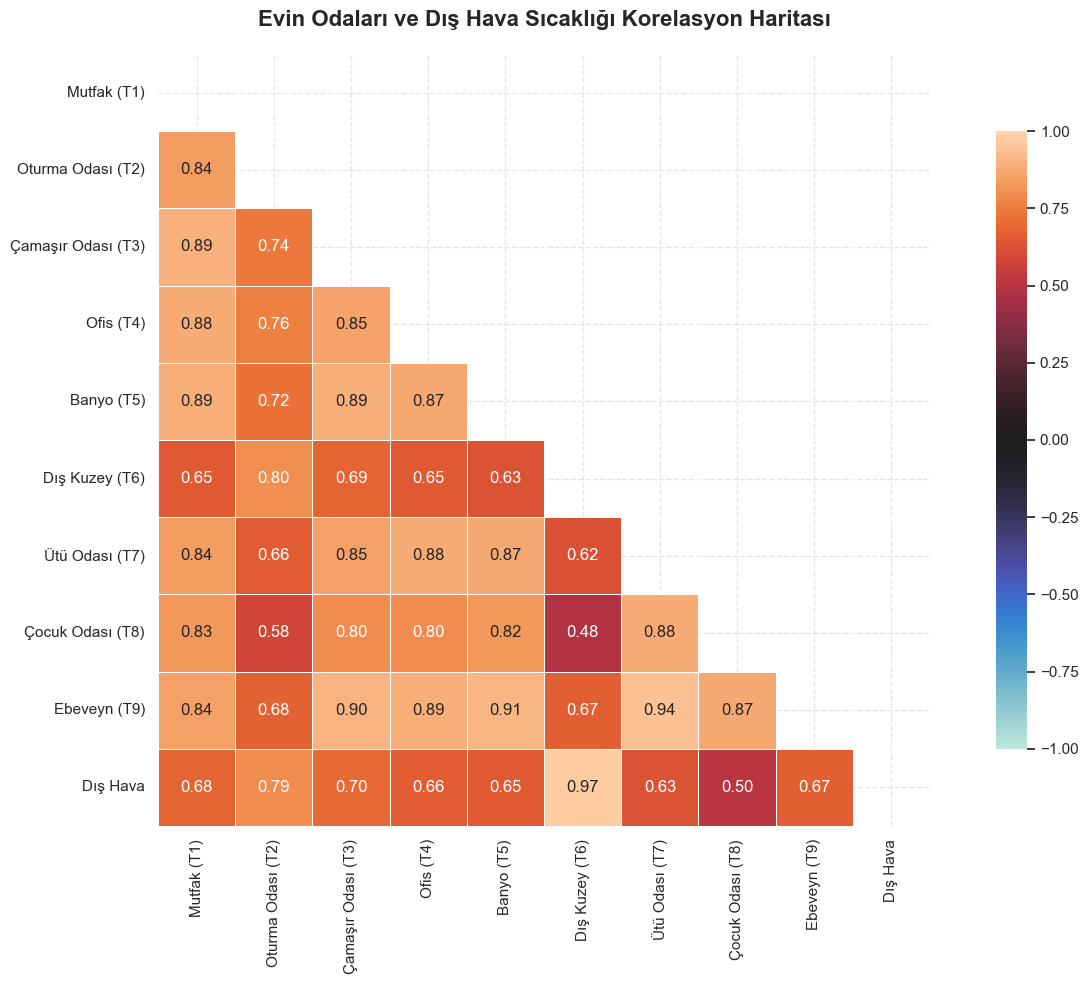

In [3]:
temperature_columns = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T_out']
df_temps = df[temperature_columns].copy()

oda_isimleri = {
    'T1': 'Mutfak (T1)', 'T2': 'Oturma Odası (T2)', 'T3': 'Çamaşır Odası (T3)',
    'T4': 'Ofis (T4)', 'T5': 'Banyo (T5)', 'T6': 'Dış Kuzey (T6)',
    'T7': 'Ütü Odası (T7)', 'T8': 'Çocuk Odası (T8)', 'T9': 'Ebeveyn (T9)',
    'T_out': 'Dış Hava'
}
df_temps.rename(columns=oda_isimleri, inplace=True)

corr_matrix = df_temps.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="icefire", 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Evin Odaları ve Dış Hava Sıcaklığı Korelasyon Haritası", pad=20)
plt.tight_layout()
plt.show()

## 2. Haftanın Günlerine Göre Tüketim Dağılımı (Violin Plot)
Kişi 1 henüz veriye 'Gün' özelliğini eklemedi, ancak biz `date` sütunundan bu bilgiyi çekerek şimdiden analiz edebiliriz.
Amacımız hafta sonu ile hafta içi enerji tüketimindeki farklılıkları (Davranış Analizi) yakalamak.

C:\Users\zeysi\AppData\Local\Temp\ipykernel_43028\3518160229.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='DayOfWeek', y='Appliances', data=df_temp, order=days_order,


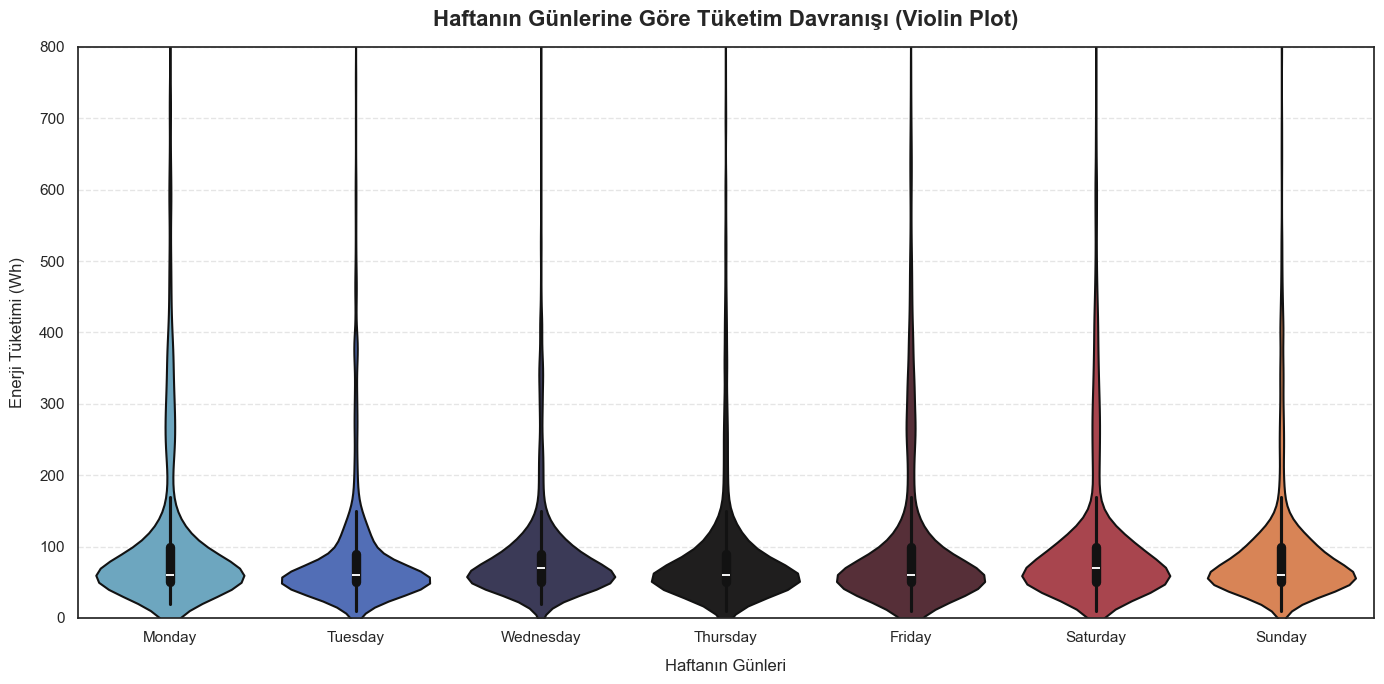

In [4]:
# Geçici olarak gün ismini çıkaralım (0=Pazartesi, 6=Pazar)
df_temp = df.copy()
df_temp['DayOfWeek'] = df_temp['date'].dt.day_name()

# Günleri sıraya koyalım
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(14, 7))

# Violin Plot ile dağılımı gösteriyoruz
# İçine boxplot ekleyerek medyanı da net şekilde veriyoruz
sns.violinplot(x='DayOfWeek', y='Appliances', data=df_temp, order=days_order, 
               palette="icefire", inner="box", linewidth=1.5)

plt.title("Haftanın Günlerine Göre Tüketim Davranışı (Violin Plot)", pad=15)
plt.xlabel("Haftanın Günleri", labelpad=10)
plt.ylabel("Enerji Tüketimi (Wh)", labelpad=10)

# Veride çok ekstrem uç değerler varsa grafiğin okunurluğunu bozmamak için y eksenini limitleyelim
plt.ylim(0, 800) 

plt.tight_layout()
plt.show()

## 3. Odaların Sıcaklık (T) ve Nem (RH) Çapraz Korelasyonu
Sadece sıcaklık veya sadece nem değil, sıcaklık yükseldiğinde nemin nasıl tepki verdiğini bulmak istiyoruz.
Devasa ve okunmaz bir 18x18 harita çizmek yerine, akademik olarak çok daha şık olan **Çapraz Korelasyon (Cross-Correlation)** haritası çizeceğiz (Satırlarda sıcaklık, sütunlarda nem).

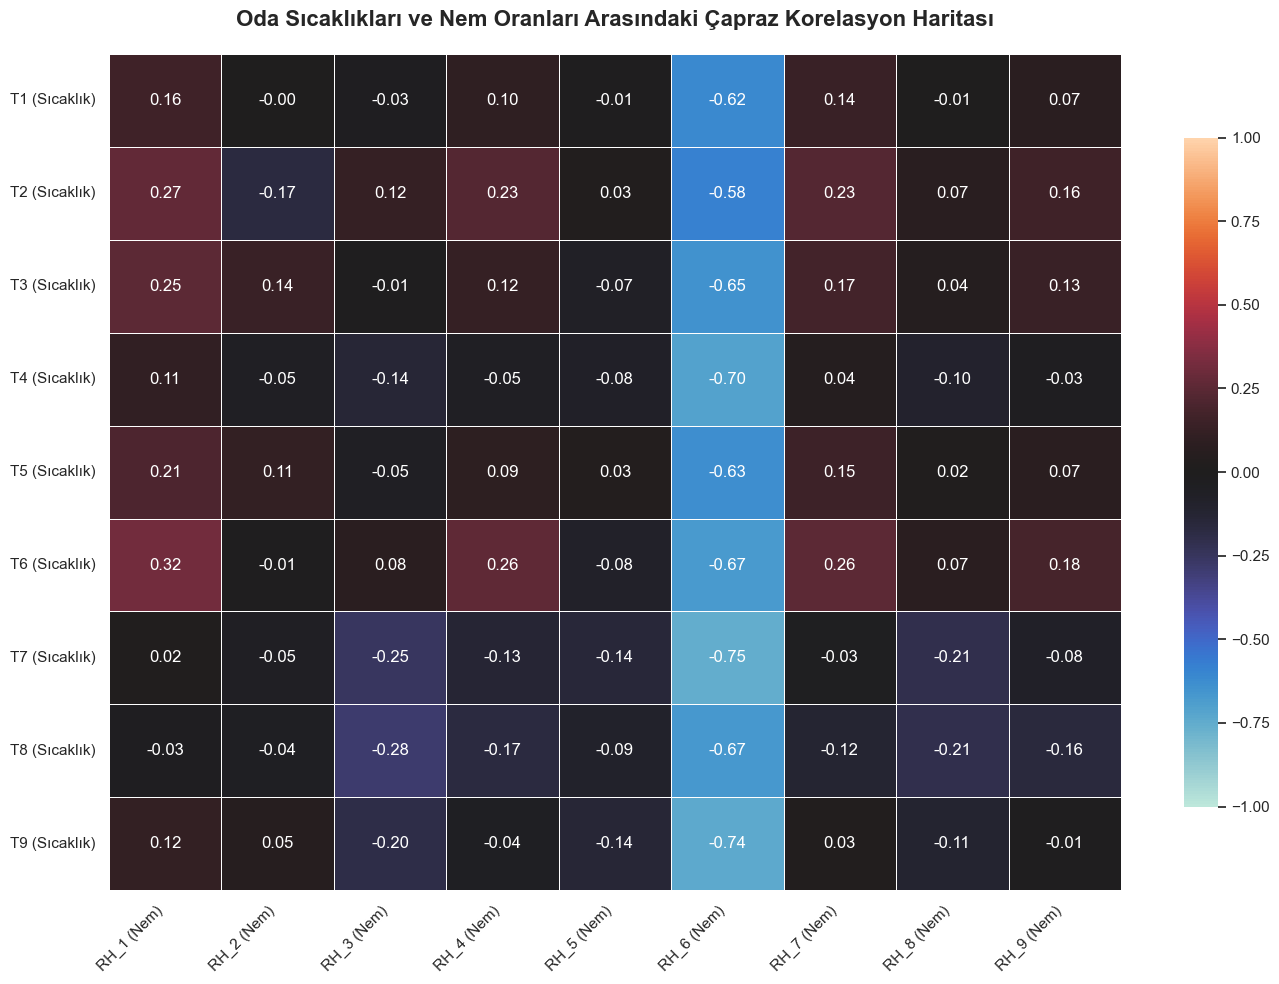

In [5]:
# Tüm T (sıcaklık) ve RH (nem) sütunlarını tanımlayalım
t_cols = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
rh_cols = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']

# Sıcaklık ve nem arasındaki korelasyonu görmek için veriyi çekelim
df_t_rh = df[t_cols + rh_cols].copy()
corr_matrix_trh = df_t_rh.corr()

# T ve RH arasındaki çapraz korelasyonu filtreleyelim (Sadece T vs RH kısmı)
cross_corr = corr_matrix_trh.loc[t_cols, rh_cols]

# Okunabilirliği artırmak için index isimlerini güzelleştirelim
t_labels = [f"T{i} (Sıcaklık)" for i in range(1, 10)]
rh_labels = [f"RH_{i} (Nem)" for i in range(1, 10)]
cross_corr.index = t_labels
cross_corr.columns = rh_labels

plt.figure(figsize=(14, 10))

# Çapraz korelasyon olduğu için mask kullanmamıza gerek yok (kare matris değil)
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap="icefire", 
            vmin=-1, vmax=1, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Oda Sıcaklıkları ve Nem Oranları Arasındaki Çapraz Korelasyon Haritası", pad=20, fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Davranışsal Radar (Polar) Grafik: 24 Saatlik Rutin (Appliances + Lights)
Bu grafik, günün 24 saatinde ortalama enerji tüketimi ve ışık kullanımını tek bakışta “rutin” olarak gösterir. Akademik sunumlarda güçlü bir hikaye anlatır (gece/sabah/akşam paternleri netleşir).

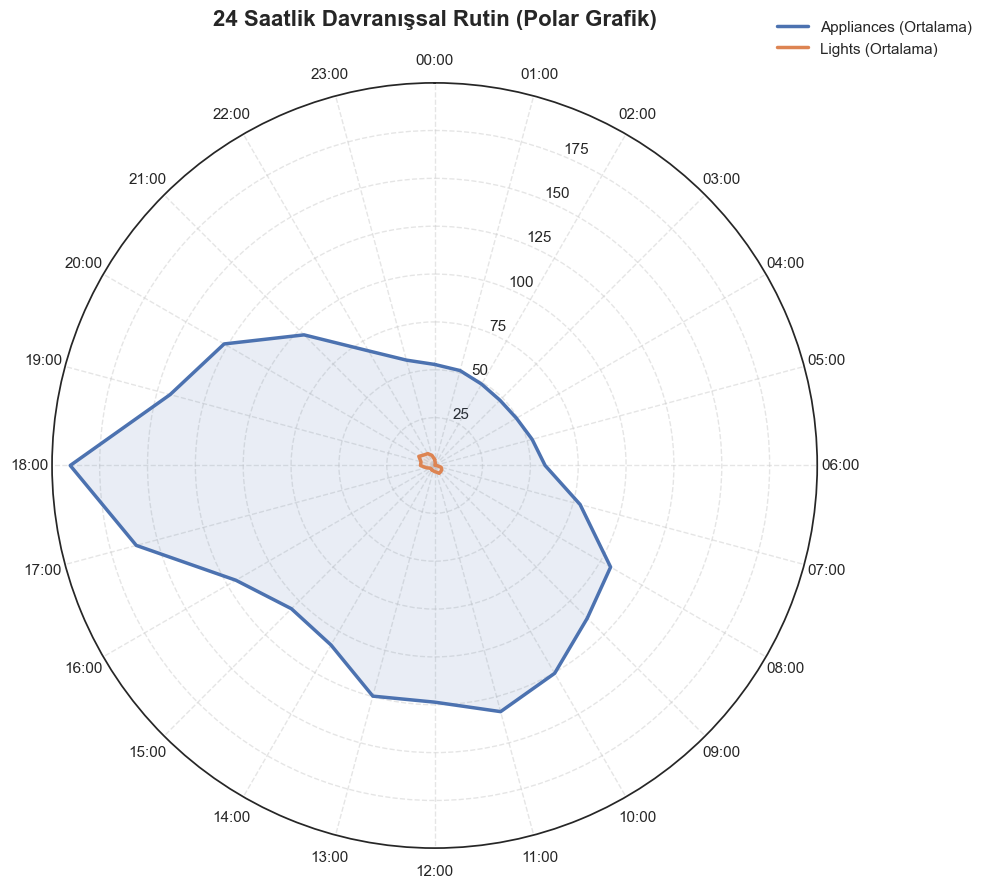

Kaydedilen grafik: outputs/behavior_radar_polar.png


In [6]:
# Polar / Radar rutin grafiği
os.makedirs('outputs', exist_ok=True)

df_polar = df.copy()
df_polar['Hour'] = df_polar['date'].dt.hour

hourly = df_polar.groupby('Hour').agg(
    Appliances_mean=('Appliances', 'mean'),
    Lights_mean=('lights', 'mean')
).reindex(range(24))

# 0-23 saatleri daireye kapatmak için son noktayı tekrar ekleyelim
hours = np.arange(24)
angles = 2 * np.pi * hours / 24
angles_closed = np.r_[angles, angles[0]]

appl = hourly['Appliances_mean'].to_numpy()
lights = hourly['Lights_mean'].to_numpy()
appl_closed = np.r_[appl, appl[0]]
lights_closed = np.r_[lights, lights[0]]

fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

ax.plot(angles_closed, appl_closed, linewidth=2.5, label='Appliances (Ortalama)')
ax.fill(angles_closed, appl_closed, alpha=0.12)

ax.plot(angles_closed, lights_closed, linewidth=2.5, label='Lights (Ortalama)')
ax.fill(angles_closed, lights_closed, alpha=0.12)

ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2)

# Etiketler
ax.set_xticks(angles)
ax.set_xticklabels([f"{h:02d}:00" for h in hours])

ax.set_title('24 Saatlik Davranışsal Rutin (Polar Grafik)', pad=20, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.22, 1.10), frameon=False)

plt.tight_layout()
plt.savefig('outputs/behavior_radar_polar.png', dpi=300)
plt.show()
print('Kaydedilen grafik: outputs/behavior_radar_polar.png')

## 5. Aykırı Değer (Anomaly) Vurgulu Zaman Serisi + Güven Bandı (Confidence Band)
Burada “normal tüketim aralığını” saat bazında (24 saatlik rutin) tanımlayıp, bunun dışına taşan noktaları kırmızı ile işaretliyoruz.

- Güven bandı: Her saat için tüketimin **%10–%90 persentil aralığı** (quantile band)
- Anomali: Bu bandın dışına çıkan noktalar

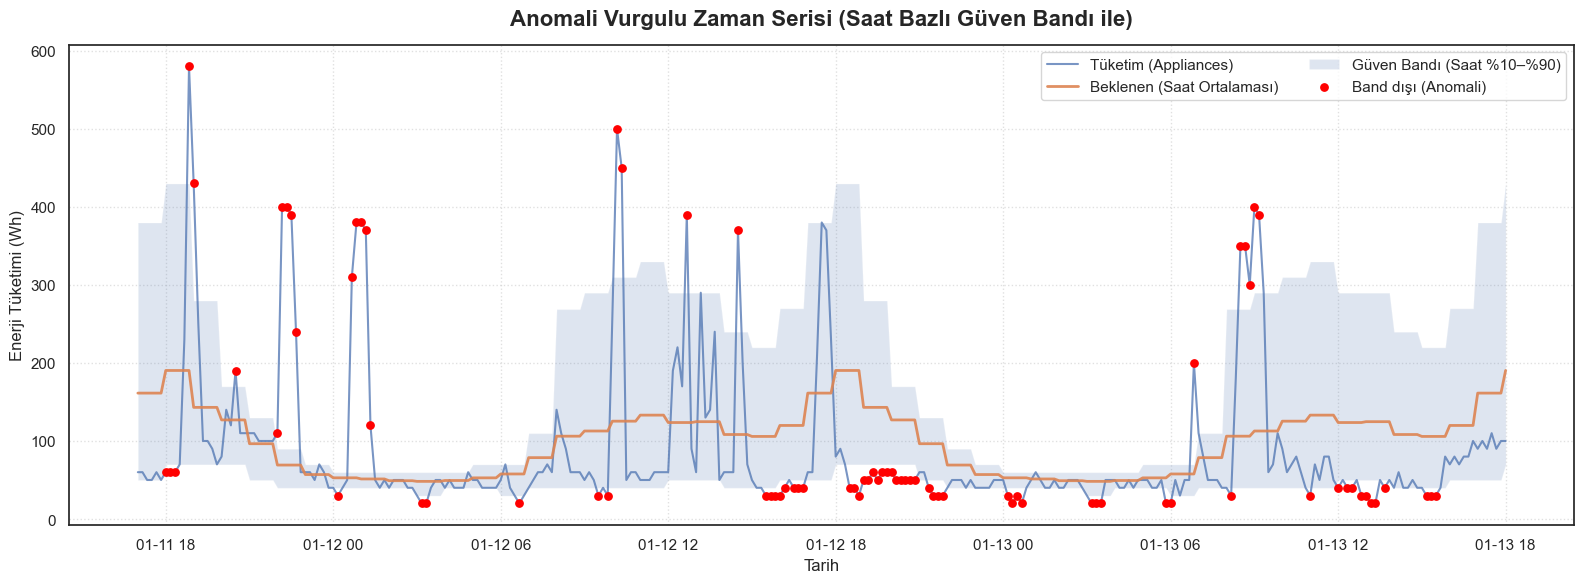

Kaydedilen grafik: outputs/anomaly_confidence_band_timeseries.png


In [7]:
# Saat bazlı güven bandı + anomali vurgusu (quantile band)
os.makedirs('outputs', exist_ok=True)

df_ci = df.copy()
df_ci['Hour'] = df_ci['date'].dt.hour

g = df_ci.groupby('Hour')['Appliances']
q10 = g.quantile(0.10)
q90 = g.quantile(0.90)
mu = g.mean()

# Her satıra saatine göre beklenen bandı taşıyalım
hour_to_q10 = q10.to_dict()
hour_to_q90 = q90.to_dict()
hour_to_mu = mu.to_dict()

df_ci['Expected_Energy'] = df_ci['Hour'].map(hour_to_mu)
df_ci['Band_Low'] = df_ci['Hour'].map(hour_to_q10)
df_ci['Band_High'] = df_ci['Hour'].map(hour_to_q90)

df_ci['is_anomaly_band'] = ((df_ci['Appliances'] < df_ci['Band_Low']) | (df_ci['Appliances'] > df_ci['Band_High'])).astype(int)

# Görsel için band-anomalisi olan bir bölümü seçelim (yoksa ilk 7 gün)
if df_ci['is_anomaly_band'].any():
    first_idx = df_ci.index[df_ci['is_anomaly_band'] == 1][0]
    center_time = df_ci.loc[first_idx, 'date']
    start = center_time - pd.Timedelta(days=2)
    end = center_time + pd.Timedelta(days=2)
    df_plot = df_ci[(df_ci['date'] >= start) & (df_ci['date'] <= end)].copy()
else:
    start = df_ci['date'].min()
    end = start + pd.Timedelta(days=7)
    df_plot = df_ci[(df_ci['date'] >= start) & (df_ci['date'] <= end)].copy()

plt.figure(figsize=(16, 6))

plt.plot(df_plot['date'], df_plot['Appliances'], label='Tüketim (Appliances)', alpha=0.75, linewidth=1.5)
plt.plot(df_plot['date'], df_plot['Expected_Energy'], label='Beklenen (Saat Ortalaması)', alpha=0.9, linewidth=2)

plt.fill_between(
    df_plot['date'],
    df_plot['Band_Low'],
    df_plot['Band_High'],
    alpha=0.18,
    label='Güven Bandı (Saat %10–%90)'
)

anom = df_plot[df_plot['is_anomaly_band'] == 1]
plt.scatter(anom['date'], anom['Appliances'], color='red', s=28, label='Band dışı (Anomali)', zorder=3)

plt.title('Anomali Vurgulu Zaman Serisi (Saat Bazlı Güven Bandı ile)', pad=14, fontweight='bold')
plt.xlabel('Tarih')
plt.ylabel('Enerji Tüketimi (Wh)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(ncol=2)
plt.tight_layout()

plt.savefig('outputs/anomaly_confidence_band_timeseries.png', dpi=300)
plt.show()
print('Kaydedilen grafik: outputs/anomaly_confidence_band_timeseries.png')